# Cleaned PCB v1i YOLOv8 Detection Baseline in Google Colab

This notebook is for the **cleaned PCB-Defect-Detection.v1i.coco detection baseline only**.

- Model: `yolov8n.pt`
- Task: object detection
- Training style: fine-tuning / transfer learning from pretrained weights
- Dataset config: `configs/pcb_v1i_coco_baseline.yaml`
- Scope: cleaned dataset only, no PKU, no DeepPCB, no tiling, no segmentation, no severity yet


## Colab Setup Notes

Use one of these project access options:

1. Put the whole repo in Google Drive and mount Drive in Colab.
2. Clone your GitHub repo into `/content/`.
3. Upload the project folder manually if needed.

The notebook below assumes **Google Drive** by default because it is the safest way to keep datasets, runs, and weights between sessions.


In [1]:
!pip install -q ultralytics==8.4.14 opencv-python pyyaml matplotlib pandas

import platform
import sys
import torch

print('Python:', sys.version)
print('Platform:', platform.platform())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    !nvidia-smi
else:
    print('GPU not detected. In Colab, switch Runtime > Change runtime type > GPU before training.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.1 MB/s eta 0:00:0000:01
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
Mon May 11 11:14:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N

## Mount Google Drive and Open the Repo

Update `PROJECT_ROOT` if your repo folder has a different Drive location.

If you prefer to clone the repo instead of using Drive, skip the mount lines and set `PROJECT_ROOT` to the cloned folder path.


In [2]:
from pathlib import Path

USE_DRIVE = True
PROJECT_ROOT = Path('/content/drive/MyDrive/PCB-Defect-Detector')  # change if needed

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

assert PROJECT_ROOT.exists(), f'Update PROJECT_ROOT to your repo folder: {PROJECT_ROOT}'

%cd $PROJECT_ROOT
print('Working directory:', PROJECT_ROOT)


Mounted at /content/drive
/content/drive/MyDrive/PCB-Defect-Detector
Working directory: /content/drive/MyDrive/PCB-Defect-Detector


## Check Dataset Paths and Prepare the YOLO Workspace

This reuses the repo's cleaned-dataset training script and config.
It validates the `train` / `valid` / `test` split paths and generates the Ultralytics data YAML without starting training yet.


In [3]:
from pathlib import Path

CONFIG_PATH = Path('configs/pcb_v1i_coco_baseline.yaml')
SCRIPT_PATH = Path('scripts/pcb_v1i_yolov8_colab_train.py')
DATA_YAML_PATH = Path('configs/pcb_v1i_yolov8_baseline_data.yaml')

assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'
assert SCRIPT_PATH.exists(), f'Missing training script: {SCRIPT_PATH}'

!python scripts/pcb_v1i_yolov8_colab_train.py --prepare-only
!cat configs/pcb_v1i_yolov8_baseline_data.yaml


CONFIG=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_coco_baseline.yaml
WORKSPACE=/content/drive/MyDrive/PCB-Defect-Detector/data/yolo_ready/pcb_v1i_yolov8_baseline
DATA_YAML=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_yolov8_baseline_data.yaml
MODEL=yolov8n.pt
RUN_NAME=yolov8n_pcb_v1i_baseline_colab
TRAIN_IMAGES=6537
TRAIN_ANNOTATIONS=7398
TRAIN_MISSING_IMAGE_REFS=0
TRAIN_MISSING_IMAGE_FILES=0
TRAIN_INVALID_CATEGORY_IDS=0
TRAIN_MALFORMED_BBOX=0
TRAIN_NONPOSITIVE_BBOX=0
TRAIN_OUT_OF_BOUNDS_BBOX=0
VAL_IMAGES=600
VAL_ANNOTATIONS=674
VAL_MISSING_IMAGE_REFS=0
VAL_MISSING_IMAGE_FILES=0
VAL_INVALID_CATEGORY_IDS=0
VAL_MALFORMED_BBOX=0
VAL_NONPOSITIVE_BBOX=0
VAL_OUT_OF_BOUNDS_BBOX=0
TEST_IMAGES=300
TEST_ANNOTATIONS=351
TEST_MISSING_IMAGE_REFS=0
TEST_MISSING_IMAGE_FILES=0
TEST_INVALID_CATEGORY_IDS=0
TEST_MALFORMED_BBOX=0
TEST_NONPOSITIVE_BBOX=0
TEST_OUT_OF_BOUNDS_BBOX=0
STATUS=Cleaned PCB v1i YOLO workspace and training data YAML are ready for Colab.
path: data/yolo_

## Baseline Training Settings

This keeps the baseline simple and detection-only.
Split usage stays fixed as:

- `train` for training
- `valid` for validation
- `test` for the post-training inference check


In [4]:
MODEL = 'yolov8n.pt'
EPOCHS = 10
IMGSZ = 640
BATCH = 16
WORKERS = 2
DEVICE = '0'
FRACTION = 1.0
PATIENCE = 20
PROJECT_DIR = 'runs/pcb_v1i_baseline'
RUN_NAME = 'yolov8n_pcb_v1i_baseline_colab'

print({
    'model': MODEL,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
    'workers': WORKERS,
    'device': DEVICE,
    'fraction': FRACTION,
    'patience': PATIENCE,
    'project_dir': PROJECT_DIR,
    'run_name': RUN_NAME,
})


{'model': 'yolov8n.pt', 'epochs': 10, 'imgsz': 640, 'batch': 16, 'workers': 2, 'device': '0', 'fraction': 1.0, 'patience': 20, 'project_dir': 'runs/pcb_v1i_baseline', 'run_name': 'yolov8n_pcb_v1i_baseline_colab'}


In [5]:
import subprocess

train_cmd = [
    'python', 'scripts/pcb_v1i_yolov8_colab_train.py',
    '--model', MODEL,
    '--epochs', str(EPOCHS),
    '--imgsz', str(IMGSZ),
    '--batch', str(BATCH),
    '--workers', str(WORKERS),
    '--device', DEVICE,
    '--fraction', str(FRACTION),
    '--patience', str(PATIENCE),
    '--project', PROJECT_DIR,
    '--name', RUN_NAME,
]

print('Running:', ' '.join(train_cmd))
subprocess.run(train_cmd, check=True)


Running: python scripts/pcb_v1i_yolov8_colab_train.py --model yolov8n.pt --epochs 10 --imgsz 640 --batch 16 --workers 2 --device 0 --fraction 1.0 --patience 20 --project runs/pcb_v1i_baseline --name yolov8n_pcb_v1i_baseline_colab


CompletedProcess(args=['python', 'scripts/pcb_v1i_yolov8_colab_train.py', '--model', 'yolov8n.pt', '--epochs', '10', '--imgsz', '640', '--batch', '16', '--workers', '2', '--device', '0', '--fraction', '1.0', '--patience', '20', '--project', 'runs/pcb_v1i_baseline', '--name', 'yolov8n_pcb_v1i_baseline_colab'], returncode=0)

## Check the Training Outputs

Ultralytics may place the run under `runs/detect/...`, so this cell checks both likely output locations.


In [6]:
from pathlib import Path
import pandas as pd

candidate_run_dirs = [
    Path(PROJECT_DIR) / RUN_NAME,
    Path('runs/detect') / PROJECT_DIR / RUN_NAME,
]

RUN_DIR = None
for candidate in candidate_run_dirs:
    if candidate.exists():
        RUN_DIR = candidate
        break

assert RUN_DIR is not None, 'Training run folder not found yet.'

print('Run directory:', RUN_DIR)
print('Best weights:', RUN_DIR / 'weights' / 'best.pt')
print('Last weights:', RUN_DIR / 'weights' / 'last.pt')

results_csv = RUN_DIR / 'results.csv'
if results_csv.exists():
    display(pd.read_csv(results_csv).tail())


Run directory: runs/detect/runs/pcb_v1i_baseline/yolov8n_pcb_v1i_baseline_colab
Best weights: runs/detect/runs/pcb_v1i_baseline/yolov8n_pcb_v1i_baseline_colab/weights/best.pt
Last weights: runs/detect/runs/pcb_v1i_baseline/yolov8n_pcb_v1i_baseline_colab/weights/last.pt


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,2705.05,1.56297,0.98593,1.45166,0.96247,0.95508,0.97944,0.53581,1.51501,0.74851,1.45892,0.000505,0.000505,0.000505
6,7,2830.38,1.52273,0.90513,1.41792,0.96132,0.94401,0.97443,0.53968,1.52634,0.71505,1.45200,0.000406,0.000406,0.000406
7,8,2957.31,1.49799,0.86410,1.40627,0.97277,0.96853,0.98155,0.54593,1.48312,0.67877,1.43403,0.000307,0.000307,0.000307
8,9,3081.89,1.46339,0.80347,1.37603,0.96430,0.97353,0.98758,0.56708,1.45751,0.63583,1.41155,0.000208,0.000208,0.000208
9,10,3206.18,1.43074,0.76408,1.35441,0.97831,0.97537,0.98915,0.57440,1.44712,0.61272,1.40394,0.000109,0.000109,0.000109


## Quick Validation / Inference Check

The training script already saves a post-training prediction check on the `test` split.
This cell displays those saved outputs if they exist, or regenerates them from `best.pt` if needed.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Prediction directory: data/inspection_outputs/yolov8n_pcb_v1i_baseline_colab_predictions


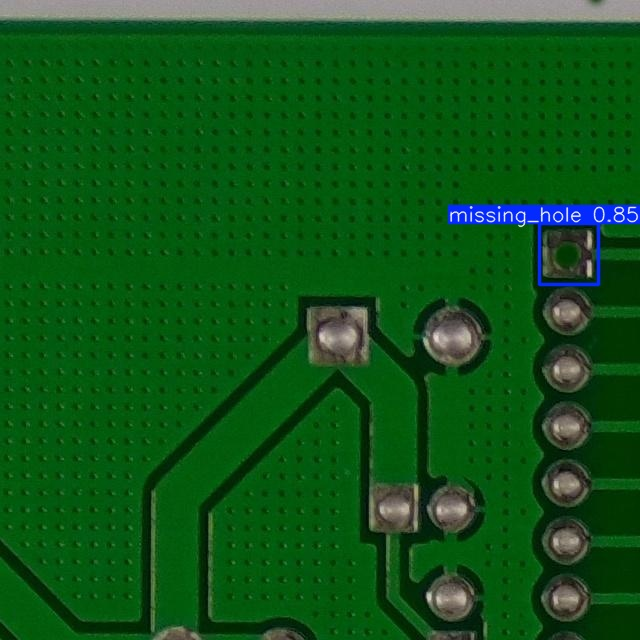

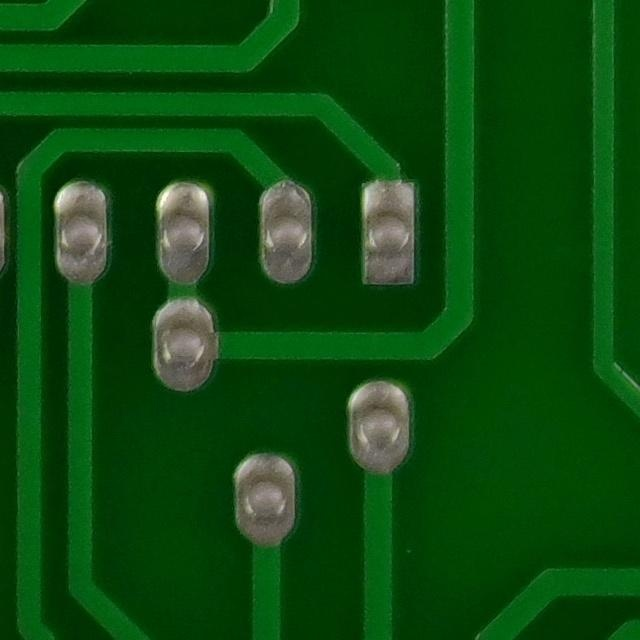

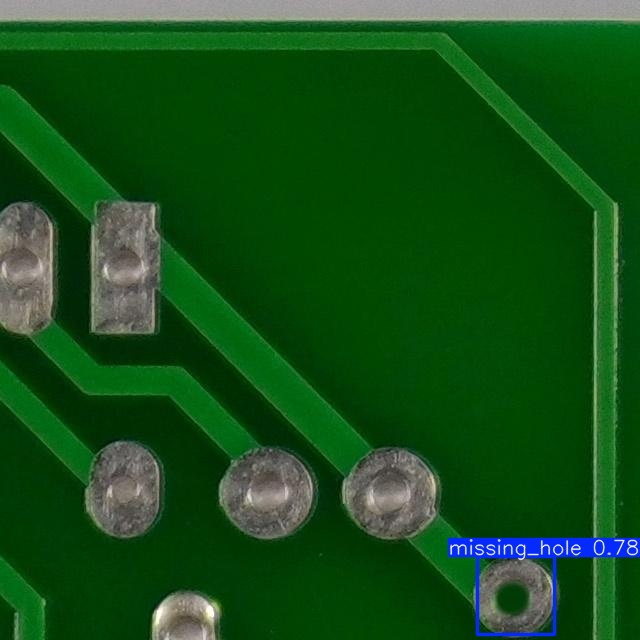

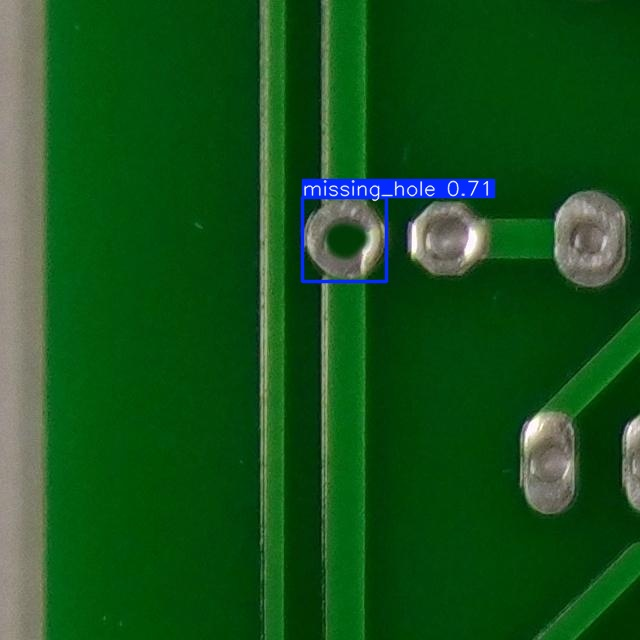

In [7]:
from pathlib import Path
from IPython.display import Image, display
from ultralytics import YOLO

best_weights = RUN_DIR / 'weights' / 'best.pt'
assert best_weights.exists(), f'Missing best weights: {best_weights}'

test_dir = Path('data/resources/PCB-Defect-Detection.v1i.coco/test')
sample_images = sorted(test_dir.glob('*.jpg'))[:8]
assert sample_images, f'No test images found in {test_dir}'

pred_root = Path('data/inspection_outputs')
pred_name = f'{RUN_NAME}_predictions'
pred_dir = pred_root / pred_name

if not pred_dir.exists() or not any(pred_dir.glob('*.jpg')):
    model = YOLO(str(best_weights))
    results = model.predict(
        source=[str(path) for path in sample_images],
        imgsz=IMGSZ,
        conf=0.25,
        device=DEVICE,
        save=True,
        project=str(pred_root),
        name=pred_name,
        exist_ok=True,
        verbose=False,
    )
    print('Predictions generated for', len(results), 'images')

print('Prediction directory:', pred_dir)
for image_path in sorted(pred_dir.glob('*.jpg'))[:4]:
    display(Image(filename=str(image_path)))


## Notes

- This notebook is for the cleaned PCB v1i dataset only.
- It keeps the workflow detection-only with pretrained `yolov8n.pt`.
- PKU, DeepPCB, tiling, segmentation, severity, augmentation, and dataset merging stay for later steps.
